# CelebA OOD Analysis

This notebook:
1. Loads classifier metrics (base + all OOD classifiers)
2. Reports test accuracy, smile/non-smile accuracy, image counts
3. Plots certified accuracy vs σ for each OOD attribute (iso vs manifold)

In [1]:
import sys, os, json, random
sys.path.insert(0, os.path.abspath(".."))

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

# ── Academic style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         11,
    'axes.labelsize':    12,
    'axes.titlesize':    13,
    'legend.fontsize':   9,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
})


# ── Colorblind-safe semantic palette (ColorBrewer) ────────────────────────────
C = {
    'manifold':   '#2166ac',   # blue   — solid line, circle marker
    'isotropic':  '#d95f02',   # orange — dashed line, square marker
    'smile':      '#1b7837',   # green  — triangle-up marker
    'no_smile':   '#762a83',   # purple — triangle-down marker
    'overall':    '#636363',   # grey   — dotted line, diamond marker
    'ood_border': '#1a9850',   # dark green — for feasible attribute borders
}
LS   = {'manifold': '-',   'isotropic': '--'}
MARK = {'manifold': 'o',   'isotropic': 's',
        'smile': '^',      'no_smile': 'v', 'overall': 'D'}

REPO_ROOT = Path(os.path.abspath(".."))
OUTPUT    = REPO_ROOT / "output"

# Classifiers
MODELS_DIR   = OUTPUT / "smile_resnet_celeba"
OOD_MODELS   = sorted([p for p in OUTPUT.iterdir()
                        if p.is_dir() and p.name.startswith("smile_resnet_celeba_ood_")])
# Certification results
CERTIFY_DIR  = OUTPUT / "smile_classification" / "celeba" / "certify_ood"

SIGMA_VALUES = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50,
                0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00, 1.50, 2.00]

def sigma_tag(v): return f'sigma_{v:.2f}'.replace('.','_')
def load_json(p):
    if not p.exists(): return None
    return json.loads(p.read_text())

print("Base model dir exists:",  MODELS_DIR.exists())
print("OOD model dirs found:",   len(OOD_MODELS))
print("Certify_ood dir exists:", CERTIFY_DIR.exists())

Base model dir exists: True
OOD model dirs found: 11
Certify_ood dir exists: True


## 1. Classifier Performance Table

In [2]:
clf_rows = []

def parse_clf_metrics(metrics_path, label):
    m = load_json(metrics_path)
    if m is None: return None
    total_test = m.get('test_smile_total', 0) + m.get('test_no_smile_total', 0)
    smile_pct  = 100 * m.get('test_smile_total',    0) / total_test if total_test else 0
    return {
        'Model':           label,
        'N test':          total_test,
        'Smile %':         round(smile_pct, 1),
        'Test acc':        round(100 * m.get('test_acc',          0), 2),
        'Smile acc':       round(100 * m.get('test_smile_acc',    0), 2),
        'Non-smile acc':   round(100 * m.get('test_no_smile_acc', 0), 2),
        'Best val acc':    round(100 * m.get('best_val_acc',      0), 2),
        'OOD exclude':     m.get('ood_exclude_attribute', None),
    }

# Base classifier
row = parse_clf_metrics(MODELS_DIR / 'metrics.json', 'Base (all data)')
if row: clf_rows.append(row)

# OOD classifiers
for d in OOD_MODELS:
    attr_name = d.name.replace('smile_resnet_celeba_ood_', '').replace('_', ' ').title()
    row = parse_clf_metrics(d / 'metrics.json', f'OOD – {attr_name}')
    if row: clf_rows.append(row)

clf_df = pd.DataFrame(clf_rows)
print(f"Classifiers loaded: {len(clf_df)}")

styled = clf_df[[
    'Model', 'N test', 'Smile %', 'Test acc', 'Smile acc', 'Non-smile acc', 'Best val acc'
]].style \
  .format({'N test': '{:,}', 'Smile %': '{:.1f}%',
           'Test acc': '{:.2f}%', 'Smile acc': '{:.2f}%',
           'Non-smile acc': '{:.2f}%', 'Best val acc': '{:.2f}%'}) \
  .background_gradient(subset=['Test acc','Smile acc','Non-smile acc'], cmap='Blues', vmin=80, vmax=100) \
  .set_caption('Classifier Performance — Base and OOD Models')
display(styled)

Classifiers loaded: 12


,Model,N test,Smile %,Test acc,Smile acc,Non-smile acc,Best val acc
0,Base (all data),"20,261",48.3%,91.97%,93.85%,90.26%,93.38%
1,OOD – Big Lips,"15,414",47.8%,91.56%,91.03%,92.02%,93.04%
2,OOD – Eyeglasses,"18,957",48.9%,92.36%,91.84%,93.05%,93.70%
3,OOD – High Cheekbones,"10,986",16.7%,90.27%,81.66%,91.99%,92.46%
4,OOD – Male,"11,809",54.4%,92.59%,91.50%,93.93%,93.75%
5,OOD – Mouth Slightly Open,"10,478",22.6%,88.74%,87.79%,89.02%,90.77%
6,OOD – Mustache,"19,427",49.1%,92.26%,93.08%,91.47%,93.46%
7,OOD – Narrow Eyes,"17,960",47.1%,92.14%,93.15%,91.21%,93.05%
8,OOD – No Beard,"3,318",35.0%,90.24%,88.29%,91.28%,91.30%
9,OOD – Rosy Cheeks,"18,947",45.5%,92.06%,91.32%,92.98%,93.02%


## 2. Figure — Classifier Accuracy Comparison

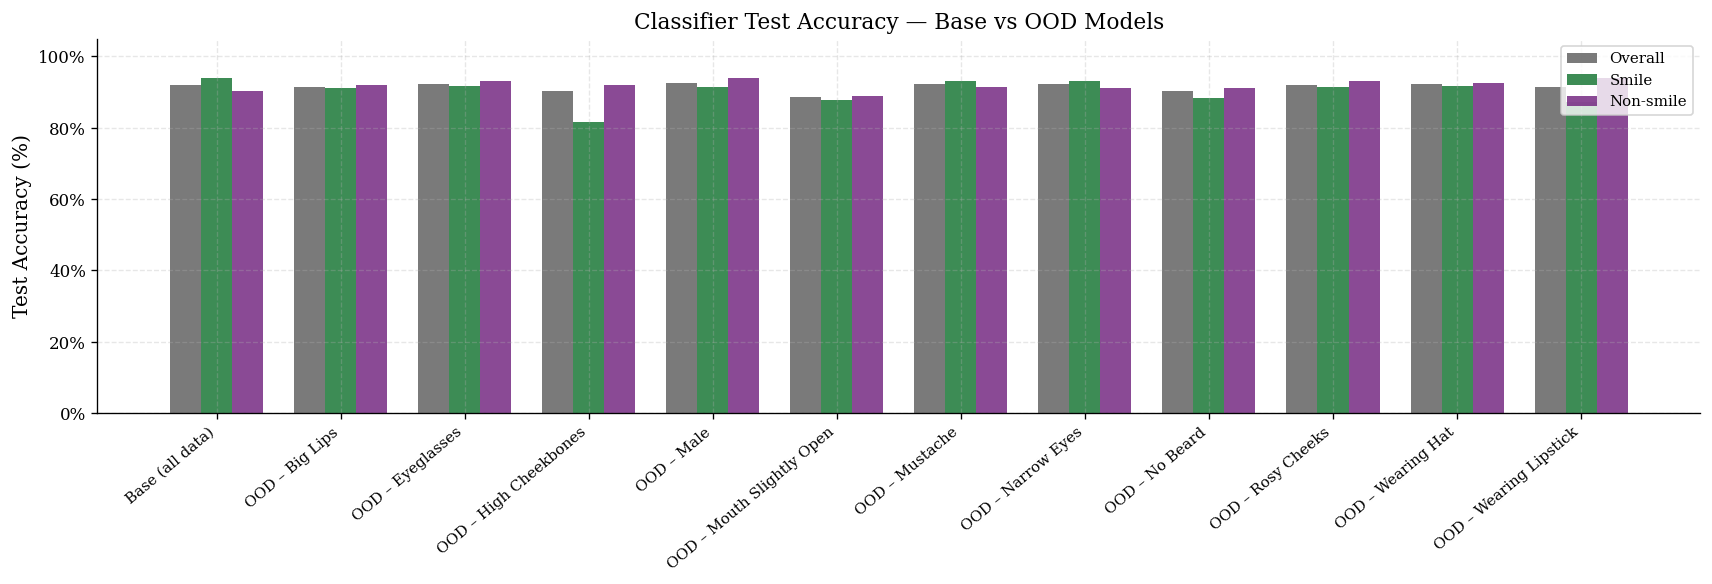

In [3]:
if not clf_df.empty:
    models  = clf_df['Model'].tolist()
    x       = np.arange(len(models))
    w       = 0.25

    fig, ax = plt.subplots(figsize=(max(10, len(models)*1.2), 5))
    ax.bar(x - w,   clf_df['Test acc'],       w, label='Overall',    color=C['overall'], alpha=0.85)
    ax.bar(x,       clf_df['Smile acc'],       w, label='Smile',      color=C['smile'], alpha=0.85)
    ax.bar(x + w,   clf_df['Non-smile acc'],   w, label='Non-smile',  color=C['no_smile'], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Classifier Test Accuracy — Base vs OOD Models')
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_clf_accuracy.pdf', bbox_inches='tight')
    plt.show()

## 3. Load OOD Certification Results

In [4]:
cert_rows = []

if not CERTIFY_DIR.exists():
    print('certify_ood not found — run OOD certification first')
else:
    for attr_dir in sorted(CERTIFY_DIR.iterdir()):
        print(attr_dir.name)
        if not attr_dir.is_dir(): continue
        attribute = attr_dir.name  # e.g. 'wearing_hat'
        
        for mode_dir in sorted(attr_dir.iterdir()):
            if not mode_dir.is_dir(): continue
            print(attribute)
            mode_raw  = mode_dir.name   # pixel_isotropic | pixel_manifold
            smoothing = 'Manifold' if 'manifold' in mode_raw else 'Isotropic'
            for s in SIGMA_VALUES:
                run_dir = mode_dir / sigma_tag(s)
                m = load_json(run_dir / 'metrics.json')
                if m is None: continue
                cert_rows.append({
                    'attribute':    attribute,
                    'smoothing':    smoothing,
                    'sigma':        float(s),
                    'certified_acc': m.get('certified_accuracy', np.nan),
                    'mean_radius':  m.get('mean_radius', np.nan),
                    'abstain_rate': m.get('abstain_rate', np.nan),
                    'smile_acc':    m.get('class_smile_accuracy', np.nan),
                    'no_smile_acc': m.get('class_no_smile_accuracy', np.nan),
                    'n_test':       m.get('total_test_samples', np.nan),
                })

cert_df = pd.DataFrame(cert_rows) if cert_rows else pd.DataFrame()
if cert_df.empty:
    print('No certification results found.')
else:
    print(f'Rows: {len(cert_df)}  Attributes: {sorted(cert_df.attribute.unique())}  Smoothing: {sorted(cert_df.smoothing.unique())}')
    display(cert_df.groupby(['attribute','smoothing'])['sigma'].count().rename('sigma_count'))

big_lips
big_lips
big_lips
mouth_slightly_open
mouth_slightly_open
mouth_slightly_open
mustache
mustache
mustache
rosy_cheeks
rosy_cheeks
rosy_cheeks
wearing_lipstick
wearing_lipstick
wearing_lipstick
Rows: 206  Attributes: ['big_lips', 'mouth_slightly_open', 'mustache', 'rosy_cheeks', 'wearing_lipstick']  Smoothing: ['Isotropic', 'Manifold']


attribute            smoothing
big_lips             Isotropic    21
                     Manifold     21
mouth_slightly_open  Isotropic    21
                     Manifold     21
mustache             Isotropic    21
                     Manifold     21
rosy_cheeks          Isotropic    20
                     Manifold     18
wearing_lipstick     Isotropic    21
                     Manifold     21
Name: sigma_count, dtype: int64

## 4. Figure — Certified Accuracy vs σ per OOD Attribute (Iso vs Manifold)

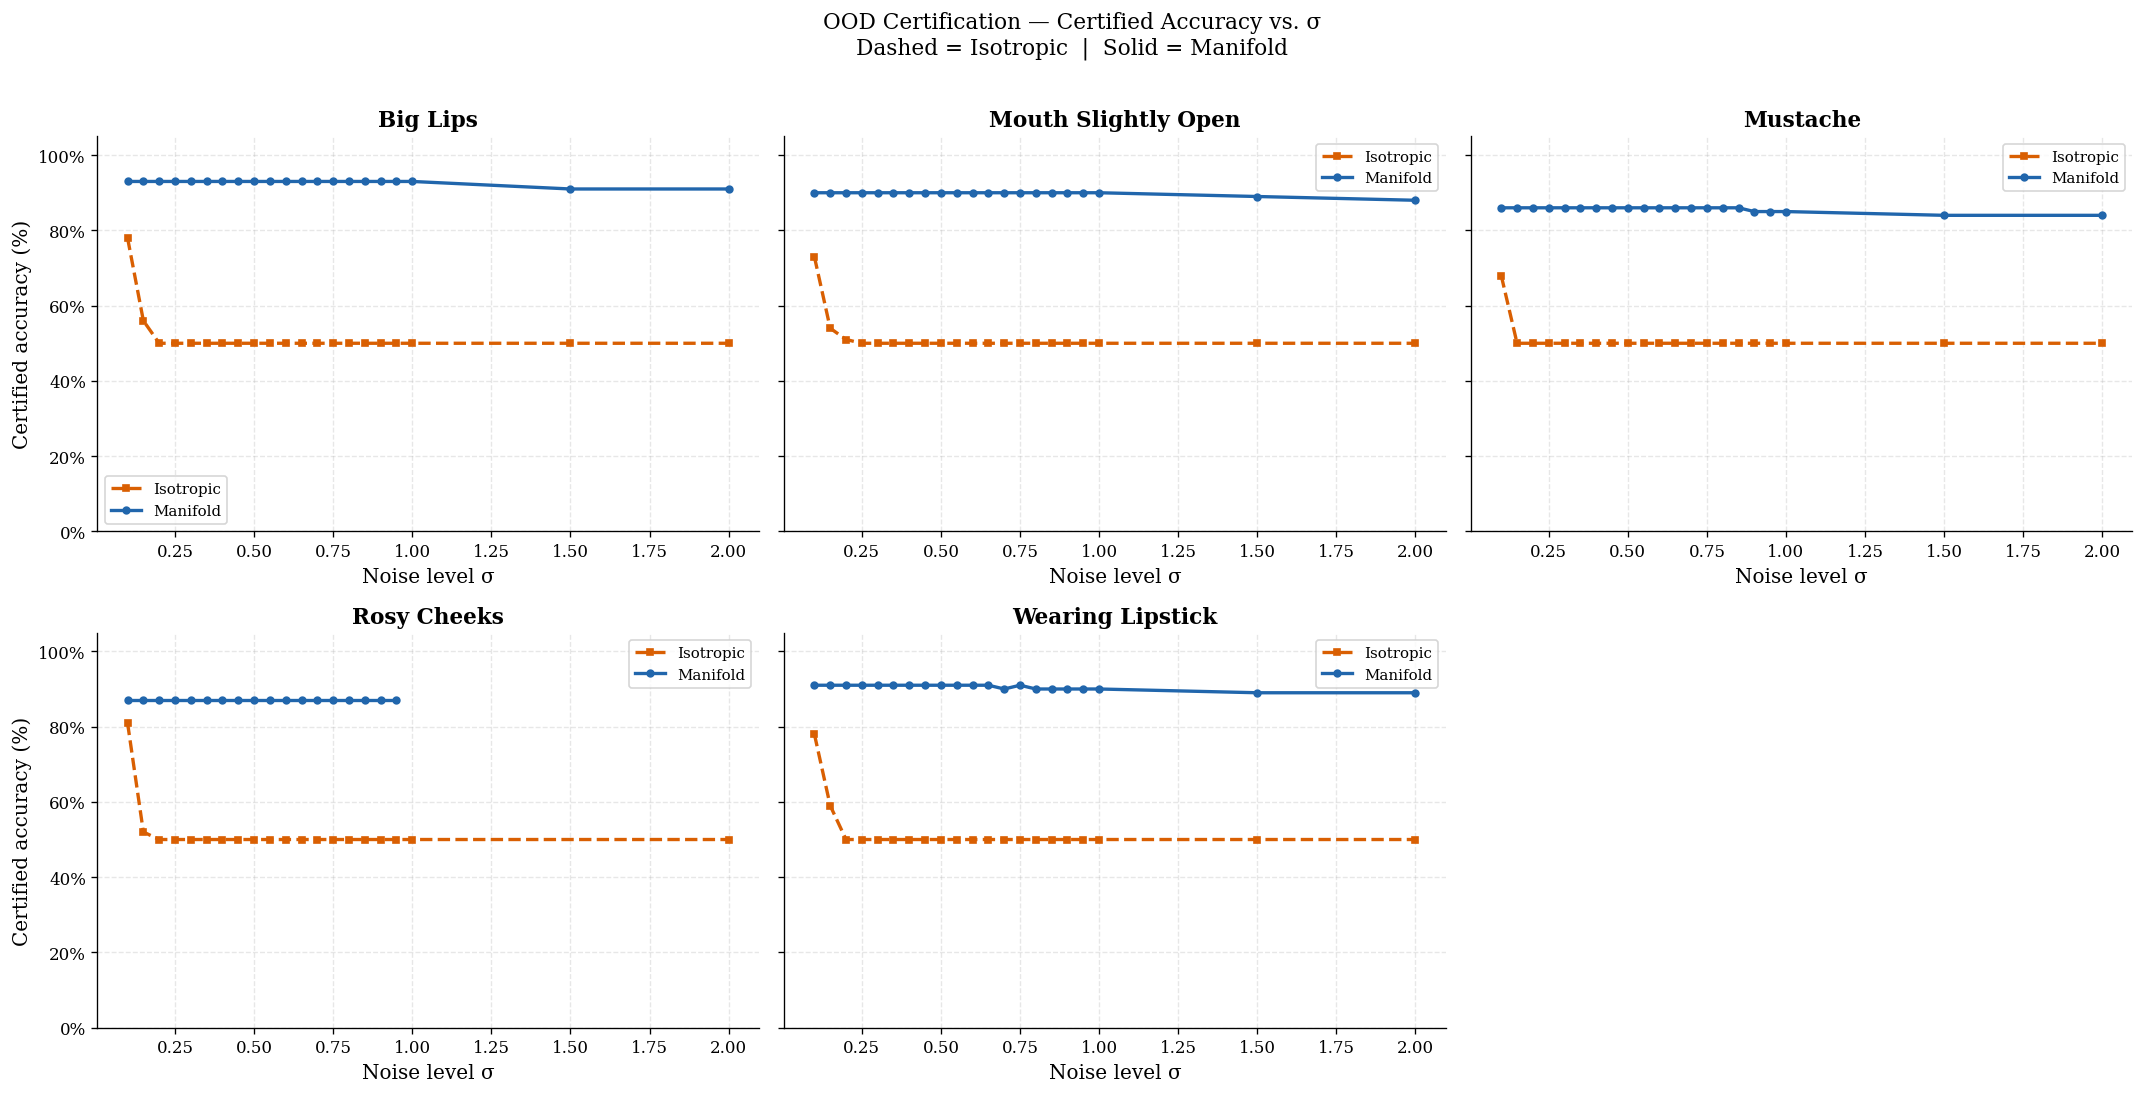

In [5]:
if not cert_df.empty:
    attributes = sorted(cert_df['attribute'].unique())
    n_attrs    = len(attributes)
    ncols      = min(3, n_attrs)
    nrows      = int(np.ceil(n_attrs / ncols))

    COLOR = {'Isotropic': C['isotropic'], 'Manifold': C['manifold']}
    LS    = {'Isotropic': '--',            'Manifold': '-'}
    MARK = {'manifold': 'o',   'isotropic': 's',
        'smile': '^',      'no_smile': 'v', 'overall': 'D'}

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4.5*nrows),
                             sharey=True, squeeze=False)

    for i, attr in enumerate(attributes):
        ax  = axes[i // ncols][i % ncols]
        sub = cert_df[cert_df['attribute'] == attr]

        for smoothing, grp in sub.groupby('smoothing'):
            grp = grp.sort_values('sigma')
            ax.plot(grp['sigma'], grp['certified_acc'] * 100,
                    color=COLOR[smoothing], linestyle=LS[smoothing],
                    marker=MARK[str.lower(smoothing)], markersize=4, linewidth=2,
                    label=smoothing)

        attr_label = attr.replace('_', ' ').title()
        ax.set_title(attr_label, fontweight='bold')
        ax.set_xlabel('Noise level σ')
        ax.set_ylabel('Certified accuracy (%)' if i % ncols == 0 else '')
        ax.set_ylim(0, 105)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.legend()

    # Hide empty subplots
    for j in range(i+1, nrows*ncols):
        axes[j // ncols][j % ncols].set_visible(False)

    fig.suptitle('OOD Certification — Certified Accuracy vs. σ\n'
                 'Dashed = Isotropic  |  Solid = Manifold',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('fig_ood_cert_acc.pdf', bbox_inches='tight')
    plt.show()

## 5. Figure — Smile vs Non-smile Certified Accuracy per Attribute

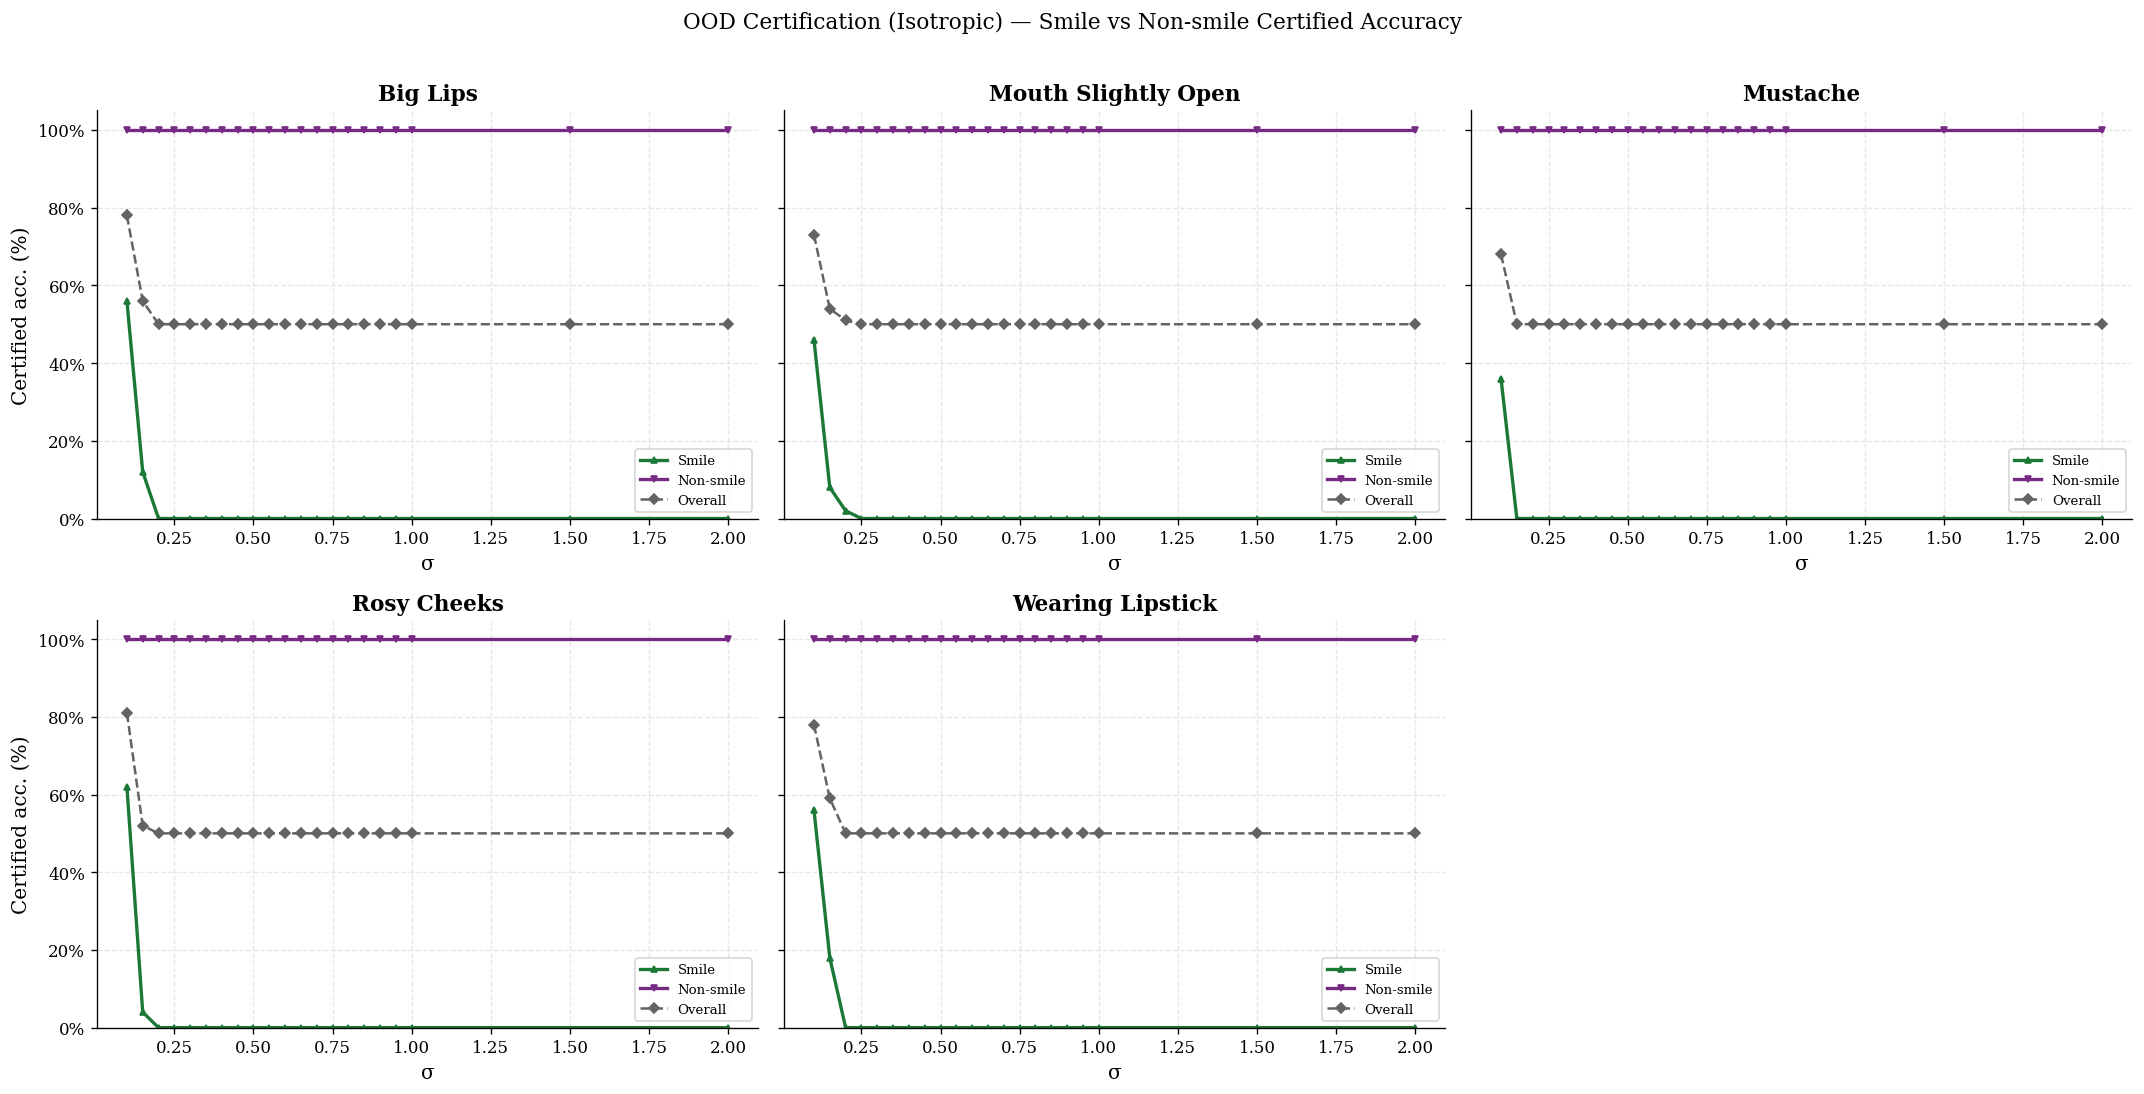

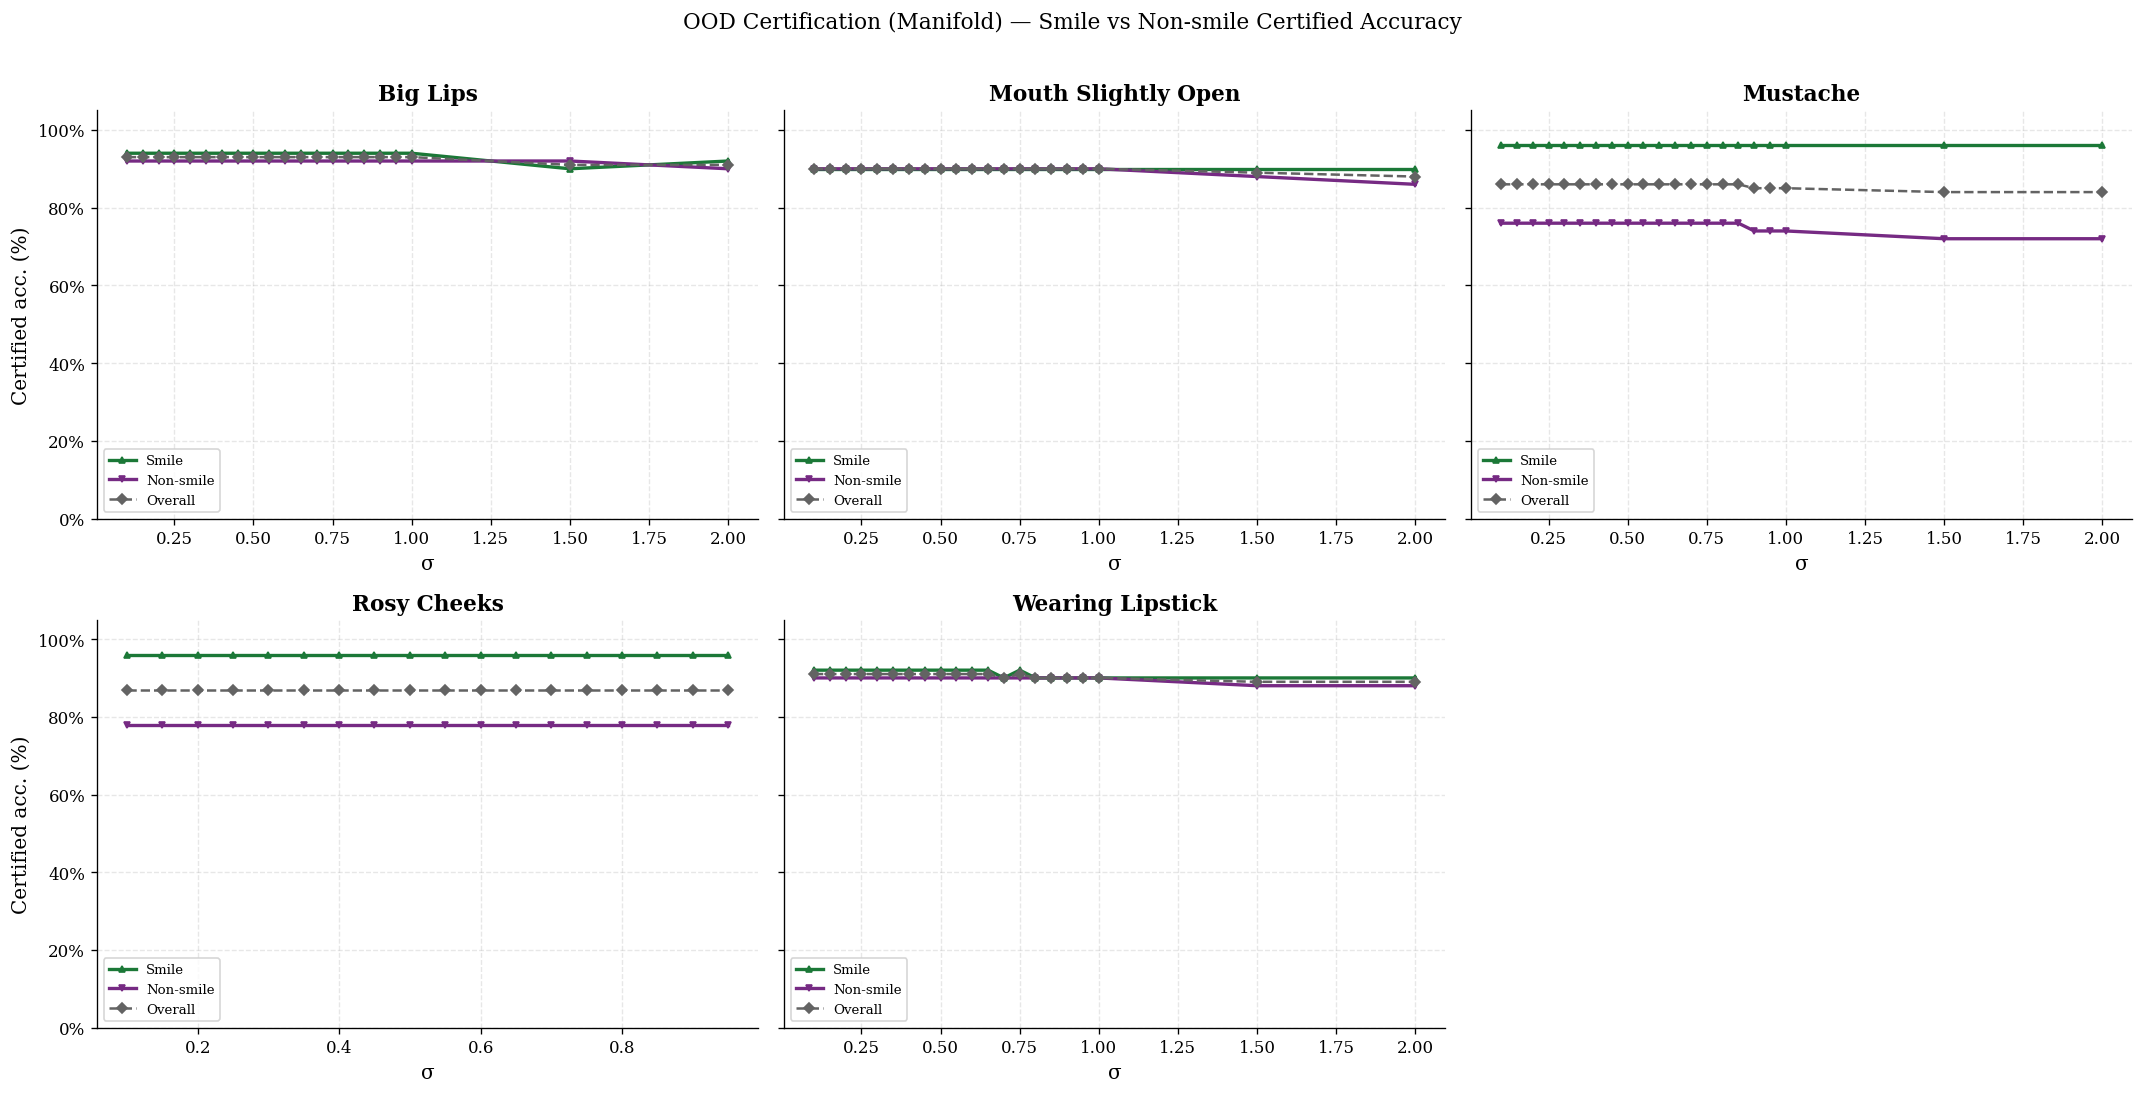

In [6]:
if not cert_df.empty:
    attributes = sorted(cert_df['attribute'].unique())
    ncols = min(3, len(attributes))
    nrows = int(np.ceil(len(attributes) / ncols))

    for smoothing in ['Isotropic', 'Manifold']:
        sub_s = cert_df[cert_df['smoothing'] == smoothing]
        if sub_s.empty: continue

        fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4.5*nrows),
                                 sharey=True, squeeze=False)

        for i, attr in enumerate(attributes):
            ax  = axes[i // ncols][i % ncols]
            sub = sub_s[sub_s['attribute'] == attr].sort_values('sigma')

            ax.plot(sub['sigma'], sub['smile_acc']    * 100,
                    color=C['smile'], marker=MARK['smile'], ms=4, lw=2, label='Smile')
            ax.plot(sub['sigma'], sub['no_smile_acc'] * 100,
                    color=C['no_smile'], marker=MARK['no_smile'], ms=4, lw=2, label='Non-smile')
            ax.plot(sub['sigma'], sub['certified_acc']* 100,
                    color=C['overall'], marker=MARK['overall'], ms=4, lw=1.5, ls='--', label='Overall')

            ax.set_title(attr.replace('_',' ').title(), fontweight='bold')
            ax.set_xlabel('σ')
            ax.set_ylabel('Certified acc. (%)' if i % ncols == 0 else '')
            ax.set_ylim(0, 105)
            ax.yaxis.set_major_formatter(mticker.PercentFormatter())
            ax.legend(fontsize=8)

        for j in range(i+1, nrows*ncols):
            axes[j // ncols][j % ncols].set_visible(False)

        fig.suptitle(f'OOD Certification ({smoothing}) — Smile vs Non-smile Certified Accuracy',
                     fontsize=13, y=1.01)
        plt.tight_layout()
        plt.savefig(f'fig_ood_{smoothing.lower()}_class_acc.pdf', bbox_inches='tight')
        plt.show()

## 6. Figure — All Attributes on One Plot (ISO vs MANI, Best σ per Attribute)

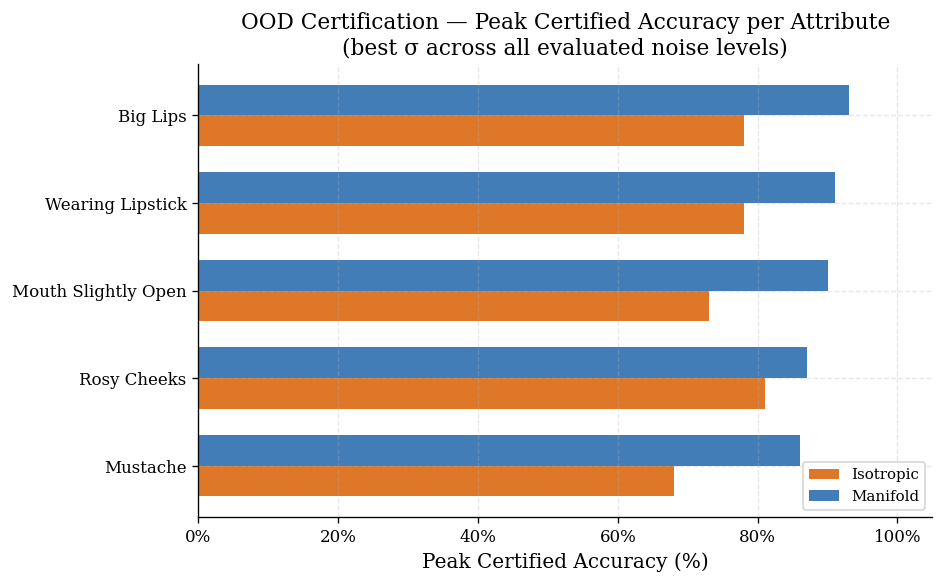

,attribute,smoothing,sigma,certified_acc,mean_radius,abstain_rate
84,mustache,Isotropic,0.10,68.00%,0.136,9.00%
42,mouth_slightly_open,Isotropic,0.10,73.00%,0.127,8.00%
0,big_lips,Isotropic,0.10,78.00%,0.139,2.00%
164,wearing_lipstick,Isotropic,0.10,78.00%,0.139,0.00%
126,rosy_cheeks,Isotropic,0.10,81.00%,0.132,3.00%
105,mustache,Manifold,0.10,86.00%,0.149,1.00%
146,rosy_cheeks,Manifold,0.10,87.00%,0.150,0.00%
63,mouth_slightly_open,Manifold,0.10,90.00%,0.148,0.00%
185,wearing_lipstick,Manifold,0.10,91.00%,0.150,0.00%
21,big_lips,Manifold,0.10,93.00%,0.149,1.00%


In [7]:
if not cert_df.empty:
    # Take the sigma with highest certified accuracy per attribute × smoothing
    best = cert_df.loc[cert_df.groupby(['attribute','smoothing'])['certified_acc'].idxmax()]
    best = best.sort_values('certified_acc', ascending=True)

    attrs_sorted = best[best['smoothing']=='Manifold'].sort_values('certified_acc')['attribute'].tolist()
    if not attrs_sorted:
        attrs_sorted = best['attribute'].unique().tolist()

    y = np.arange(len(attrs_sorted))
    w = 0.35

    iso_vals  = [best.query(f"attribute=='{a}' and smoothing=='Isotropic'")['certified_acc'].values
                 for a in attrs_sorted]
    mani_vals = [best.query(f"attribute=='{a}' and smoothing=='Manifold'")['certified_acc'].values
                 for a in attrs_sorted]

    iso_vals  = [v[0]*100 if len(v) else np.nan for v in iso_vals]
    mani_vals = [v[0]*100 if len(v) else np.nan for v in mani_vals]

    fig, ax = plt.subplots(figsize=(8, max(5, len(attrs_sorted)*0.45)))
    ax.barh(y - w/2, iso_vals,  w, label='Isotropic', color=C['isotropic'], alpha=0.85)
    ax.barh(y + w/2, mani_vals, w, label='Manifold',  color=C['manifold'], alpha=0.85)

    ax.set_yticks(y)
    ax.set_yticklabels([a.replace('_',' ').title() for a in attrs_sorted])
    ax.set_xlabel('Peak Certified Accuracy (%)')
    ax.set_title('OOD Certification — Peak Certified Accuracy per Attribute\n'
                 '(best σ across all evaluated noise levels)')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_xlim(0, 105)
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_ood_peak_acc.pdf', bbox_inches='tight')
    plt.show()

    # Also print the best-sigma table
    display(best[['attribute','smoothing','sigma','certified_acc','mean_radius','abstain_rate']]
            .style.format({'sigma':'{:.2f}','certified_acc':'{:.2%}',
                           'mean_radius':'{:.3f}','abstain_rate':'{:.2%}'}))

## 7. Figure — Certified Radius vs σ (ISO vs MANI)

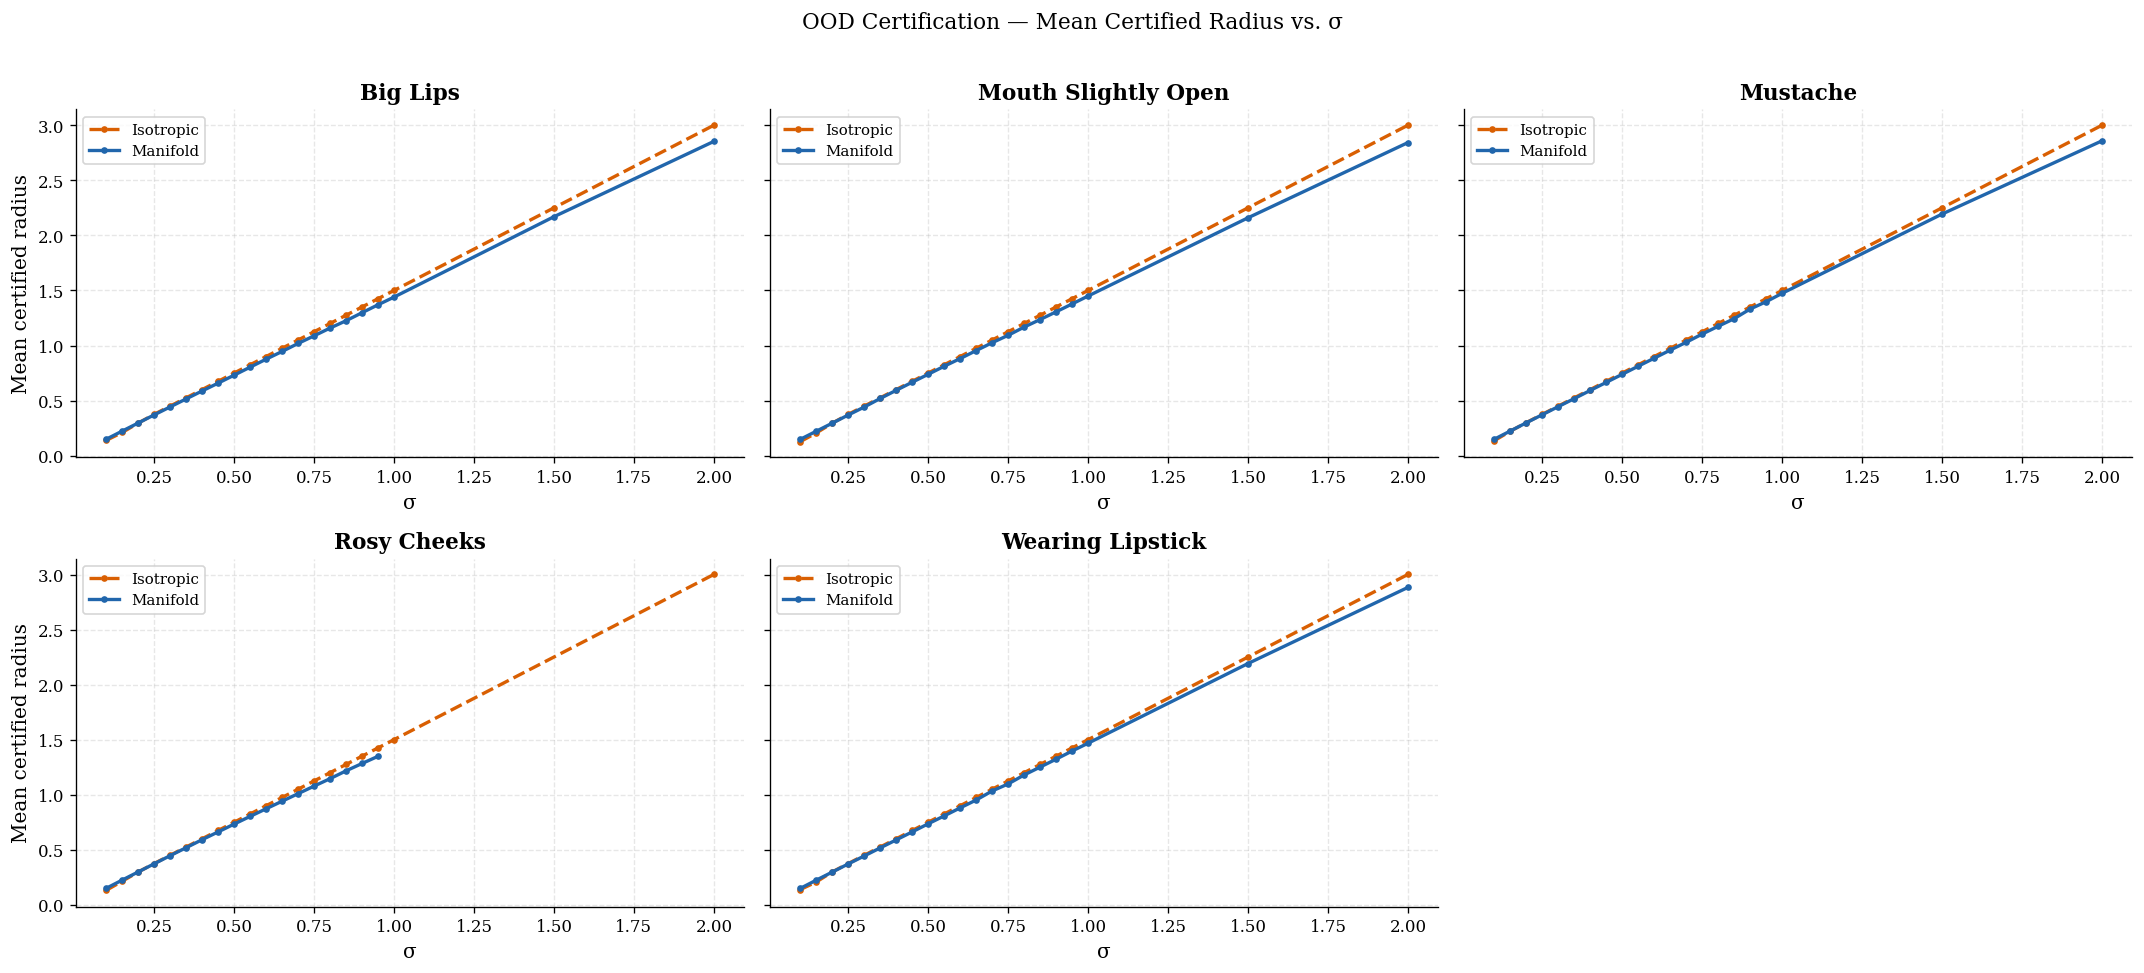

In [8]:
if not cert_df.empty:
    attributes = sorted(cert_df['attribute'].unique())
    ncols = min(3, len(attributes))
    nrows = int(np.ceil(len(attributes) / ncols))
    COLOR = {'Isotropic': C['isotropic'], 'Manifold': C['manifold']}
    LS    = {'Isotropic': '--',            'Manifold': '-'}

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows),
                             sharey=True, squeeze=False)
    for i, attr in enumerate(attributes):
        ax  = axes[i // ncols][i % ncols]
        sub = cert_df[cert_df['attribute'] == attr]
        for smoothing, grp in sub.groupby('smoothing'):
            grp = grp.sort_values('sigma')
            ax.plot(grp['sigma'], grp['mean_radius'],
                    color=COLOR[smoothing], ls=LS[smoothing],
                    marker='o', ms=3, lw=2, label=smoothing)
        ax.set_title(attr.replace('_',' ').title(), fontweight='bold')
        ax.set_xlabel('σ')
        ax.set_ylabel('Mean certified radius' if i % ncols == 0 else '')
        ax.legend()
    for j in range(i+1, nrows*ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    fig.suptitle('OOD Certification — Mean Certified Radius vs. σ', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('fig_ood_radius.pdf', bbox_inches='tight')
    plt.show()